Missing Values:
Children apprehended and placed in CBP custody*     450
Children in CBP custody                             450
Children transferred out of CBP custody             450
Children in HHS Care                               1170
Children discharged from HHS Care                   450
dtype: int64

Duplicate Dates:
449

===== KPI SUMMARY =====
Average Total System Load: nan
Maximum System Load: nan
Average Net Intake: -44.74
Maximum Growth Rate: nan


/tmp/ipykernel_586/385533650.py:51: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Total_System_Load'].pct_change() * 100


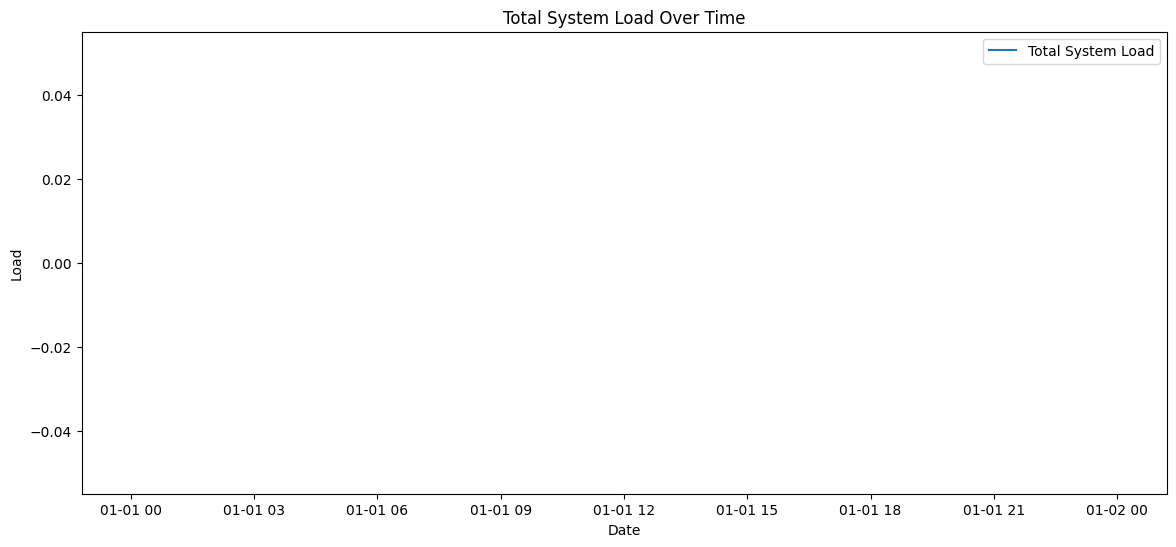

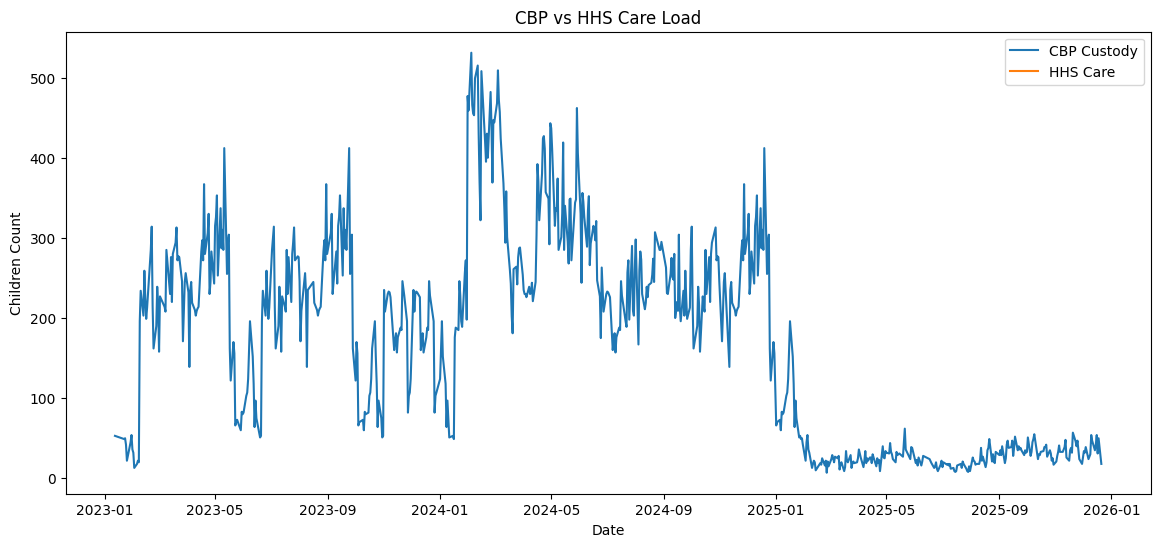

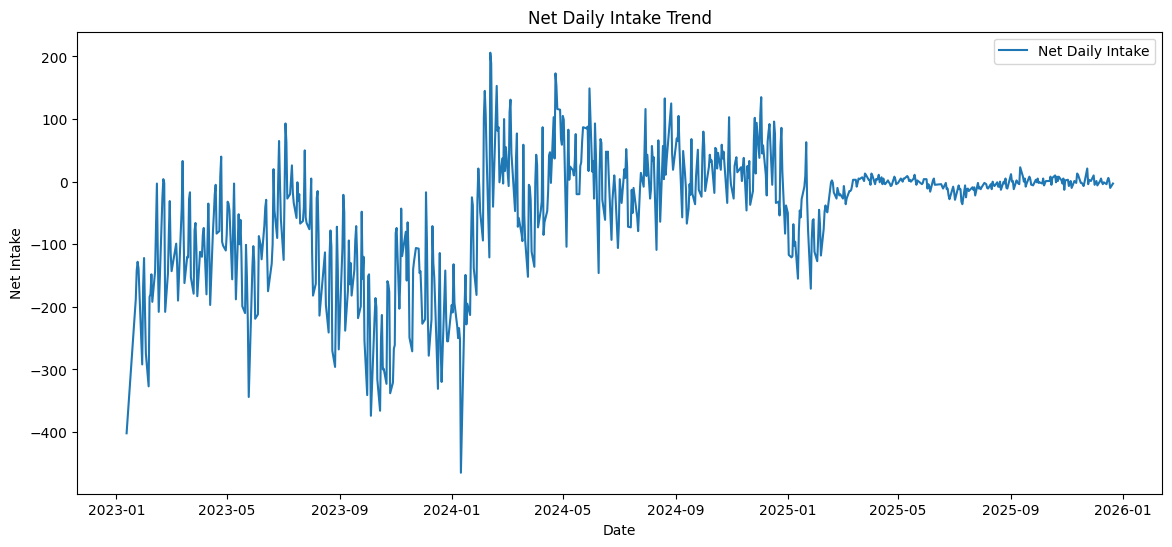

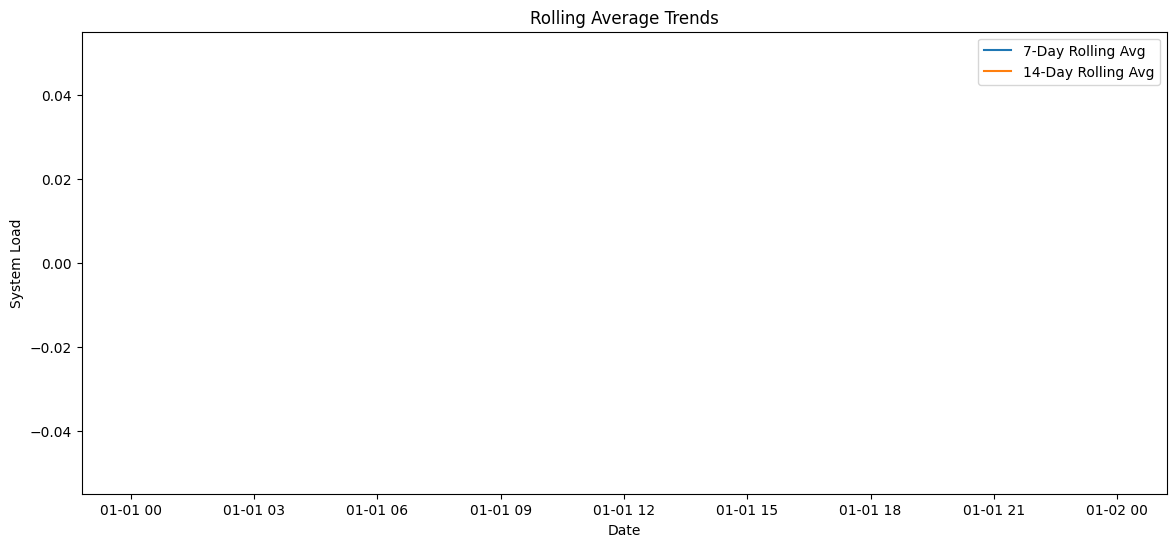


PROJECT EXECUTED SUCCESSFULLY


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('HHS_Unaccompanied_Alien_Children_Program (1).csv')

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values('Date')

# Set date as index
df.set_index('Date', inplace=True)

# Convert relevant columns to numeric, coercing errors
df['Children in CBP custody'] = pd.to_numeric(df['Children in CBP custody'], errors='coerce')
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')
df['Children transferred out of CBP custody'] = pd.to_numeric(df['Children transferred out of CBP custody'], errors='coerce')
df['Children discharged from HHS Care'] = pd.to_numeric(df['Children discharged from HHS Care'], errors='coerce')

# ==============================
# DATA QUALITY CHECKS
# ==============================

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Dates:")
print(df.index.duplicated().sum())

# ==============================
# DERIVED METRICS
# ==============================

# Total System Load
df['Total_System_Load'] = (
    df['Children in CBP custody'] +
    df['Children in HHS Care']
)

# Net Daily Intake
df['Net_Daily_Intake'] = (
    df['Children transferred out of CBP custody'] -
    df['Children discharged from HHS Care']
)

# Growth Rate
df['Care_Load_Growth_Rate'] = (
    df['Total_System_Load'].pct_change() * 100
)

# Rolling averages
df['Rolling_7_Day'] = (
    df['Total_System_Load'].rolling(7).mean()
)

df['Rolling_14_Day'] = (
    df['Total_System_Load'].rolling(14).mean()
)

# ==============================
# KPI SUMMARY
# ==============================

print("\n===== KPI SUMMARY =====")

print("Average Total System Load:",
      round(df['Total_System_Load'].mean(),2))

print("Maximum System Load:",
      round(df['Total_System_Load'].max(),2))

print("Average Net Intake:",
      round(df['Net_Daily_Intake'].mean(),2))

print("Maximum Growth Rate:",
      round(df['Care_Load_Growth_Rate'].max(),2))

# ==============================
# PLOT 1
# TOTAL SYSTEM LOAD
# ==============================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Total_System_Load'],
    label='Total System Load'
)

plt.title('Total System Load Over Time')

plt.xlabel('Date')
plt.ylabel('Load')

plt.legend()

plt.show()

# ==============================
# PLOT 2
# CBP vs HHS
# ==============================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Children in CBP custody'],
    label='CBP Custody'
)

plt.plot(
    df.index,
    df['Children in HHS Care'],
    label='HHS Care'
)

plt.title('CBP vs HHS Care Load')

plt.xlabel('Date')
plt.ylabel('Children Count')

plt.legend()

plt.show()

# ==============================
# PLOT 3
# NET DAILY INTAKE
# ==============================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Net_Daily_Intake'],
    label='Net Daily Intake'
)

plt.title('Net Daily Intake Trend')

plt.xlabel('Date')
plt.ylabel('Net Intake')

plt.legend()

plt.show()

# ==============================
# PLOT 4
# ROLLING AVERAGES
# ==============================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Rolling_7_Day'],
    label='7-Day Rolling Avg'
)

plt.plot(
    df.index,
    df['Rolling_14_Day'],
    label='14-Day Rolling Avg'
)

plt.title('Rolling Average Trends')

plt.xlabel('Date')
plt.ylabel('System Load')

plt.legend()

plt.show()

print("\nPROJECT EXECUTED SUCCESSFULLY")